# Will the Customer Accept the Coupon?
**Practical Application Assignment 5.1**
*UCI Machine Learning Repository — In-Vehicle Coupon Recommendation Dataset*

---

## Problem Statement

A driver receives a coupon recommendation while behind the wheel. Will they accept it?

Using 12,684 survey responses from Amazon Mechanical Turk, we use exploratory data analysis, visualizations, and probability distributions to distinguish customers who accepted a driving coupon from those who did not. Our focused deep-dive examines **Bar coupons** specifically.

---


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.figsize': (9, 5)})
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)


## 2. Load & Inspect the Data

In [2]:
df = pd.read_csv('coupons.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (12684, 26)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
destination,12684,3,No Urgent Place,6283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
passanger,12684,4,Alone,7305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,12684,3,Sunny,10069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature,12684.000,NaN,NaN,NaN,63.302,19.154,30.000,55.000,80.000,80.000,80.000
time,12684,5,6PM,3230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coupon,12684,5,Coffee House,3996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expiration,12684,2,1d,7091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,12684,2,Female,6511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,12684,8,21,2653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
maritalStatus,12684,5,Married partner,5100,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Quality & Cleaning

In [5]:
# Missing value audit
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'pct': missing_pct})
print(missing_report[missing_report.missing_count > 0])


                      missing_count    pct
car                           12576 99.150
CoffeeHouse                     217  1.710
Restaurant20To50                189  1.490
CarryAway                       151  1.190
RestaurantLessThan20            130  1.020
Bar                             107  0.840


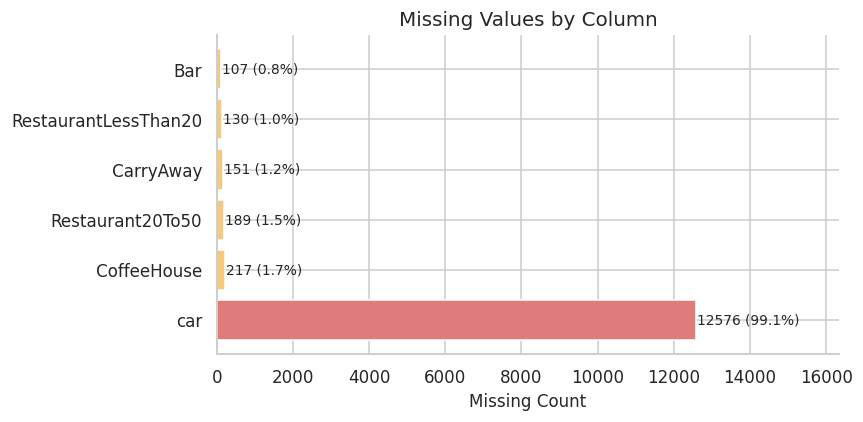

In [6]:
# Visualise missing data
missing_cols = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_cols.index, missing_cols.values,
        color=['#e07b7b' if v > 1000 else '#f4c97b' for v in missing_cols.values],
        edgecolor='white')
ax.set_xlabel('Missing Count')
ax.set_title('Missing Values by Column')
for i, v in enumerate(missing_cols.values):
    ax.text(v + 30, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_xlim(0, missing_cols.max() * 1.3)
sns.despine()
plt.tight_layout()
plt.savefig('fig_missing.png', bbox_inches='tight')
plt.show()


In [7]:
# 'car' has 99.1% missing — drop it (not useful)
# For other columns drop rows with NaN (<2% of data total)
df.drop(columns=['car'], inplace=True)
df.dropna(inplace=True)
print(f"Cleaned shape: {df.shape}")
print(f"Rows removed: {12684 - len(df)}")


Cleaned shape: (12079, 25)
Rows removed: 605


## 4. Overall Coupon Acceptance Rate

Overall acceptance rate : 56.9%
Overall rejection rate  : 43.1%


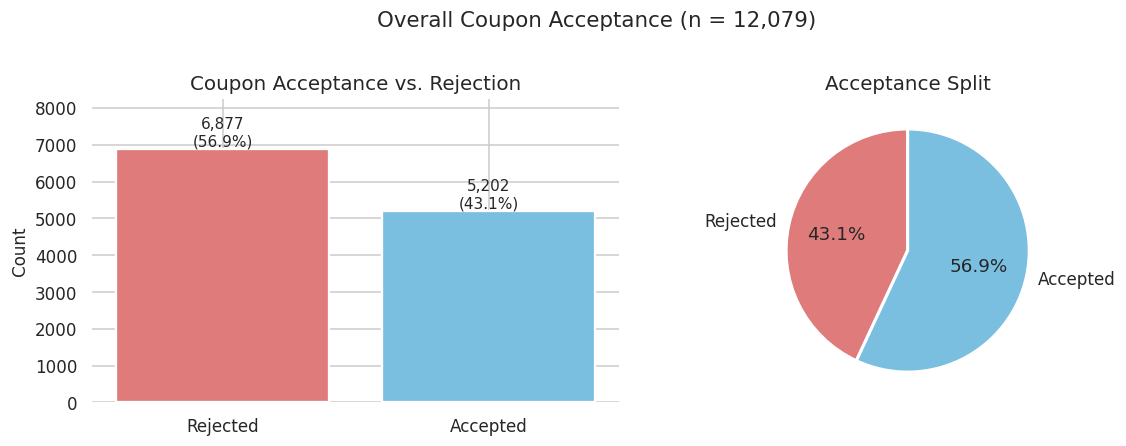

In [8]:
accept_rate = df['Y'].mean()
reject_rate = 1 - accept_rate
print(f"Overall acceptance rate : {accept_rate:.1%}")
print(f"Overall rejection rate  : {reject_rate:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count bar
counts = df['Y'].value_counts()
axes[0].bar(['Rejected', 'Accepted'], counts.values,
            color=['#e07b7b', '#7bbfe0'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Coupon Acceptance vs. Rejection')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 80, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)
axes[0].set_ylim(0, counts.max() * 1.2)

# Pie
axes[1].pie([reject_rate, accept_rate],
            labels=['Rejected', 'Accepted'],
            autopct='%1.1f%%',
            colors=['#e07b7b', '#7bbfe0'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Acceptance Split')

for ax in axes:
    sns.despine(ax=ax, left=True, bottom=True)
plt.suptitle('Overall Coupon Acceptance (n = {:,})'.format(len(df)), fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_overall.png', bbox_inches='tight')
plt.show()


## 5. Acceptance Rate by Coupon Type

                       rate     n  rate_pct
coupon                                     
Carry out & Take away 0.738  2280    73.772
Restaurant(<20)       0.709  2653    70.901
Coffee House          0.496  3816    49.633
Restaurant(20-50)     0.446  1417    44.601
Bar                   0.412  1913    41.192


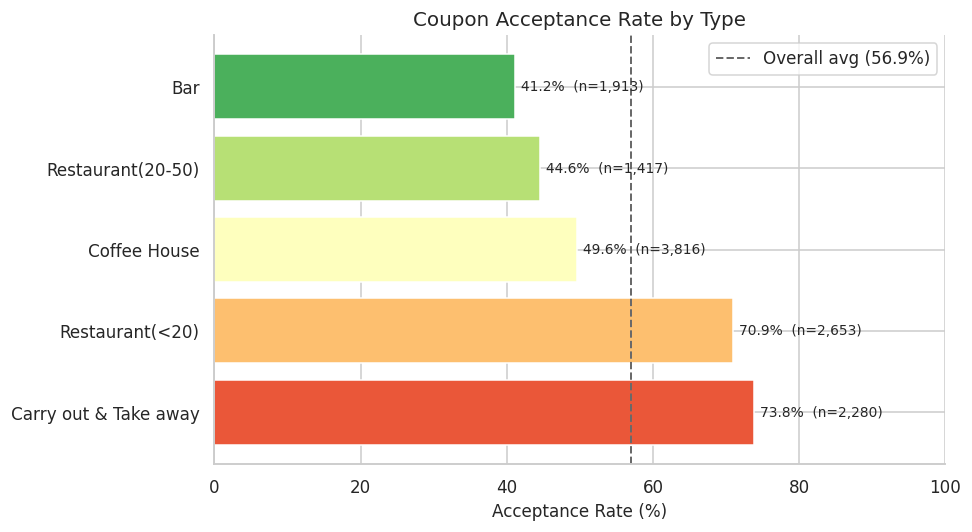

In [9]:
coupon_stats = (df.groupby('coupon')['Y']
                .agg(['mean','count'])
                .rename(columns={'mean':'rate','count':'n'})
                .sort_values('rate', ascending=False))
coupon_stats['rate_pct'] = coupon_stats['rate'] * 100
print(coupon_stats.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('RdYlGn', len(coupon_stats))
bars = ax.barh(coupon_stats.index, coupon_stats['rate_pct'],
               color=colors, edgecolor='white')
ax.axvline(accept_rate * 100, color='dimgray', linestyle='--', linewidth=1.3,
           label=f'Overall avg ({accept_rate:.1%})')
ax.set_xlabel('Acceptance Rate (%)')
ax.set_title('Coupon Acceptance Rate by Type')
ax.set_xlim(0, 100)
ax.legend()
for bar, (_, row) in zip(bars, coupon_stats.iterrows()):
    ax.text(row['rate_pct'] + 0.8, bar.get_y() + bar.get_height()/2,
            f"{row['rate_pct']:.1f}%  (n={int(row['n']):,})", va='center', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('fig_by_type.png', bbox_inches='tight')
plt.show()


## 6. Context Factors — Weather, Time, Expiration, Passenger

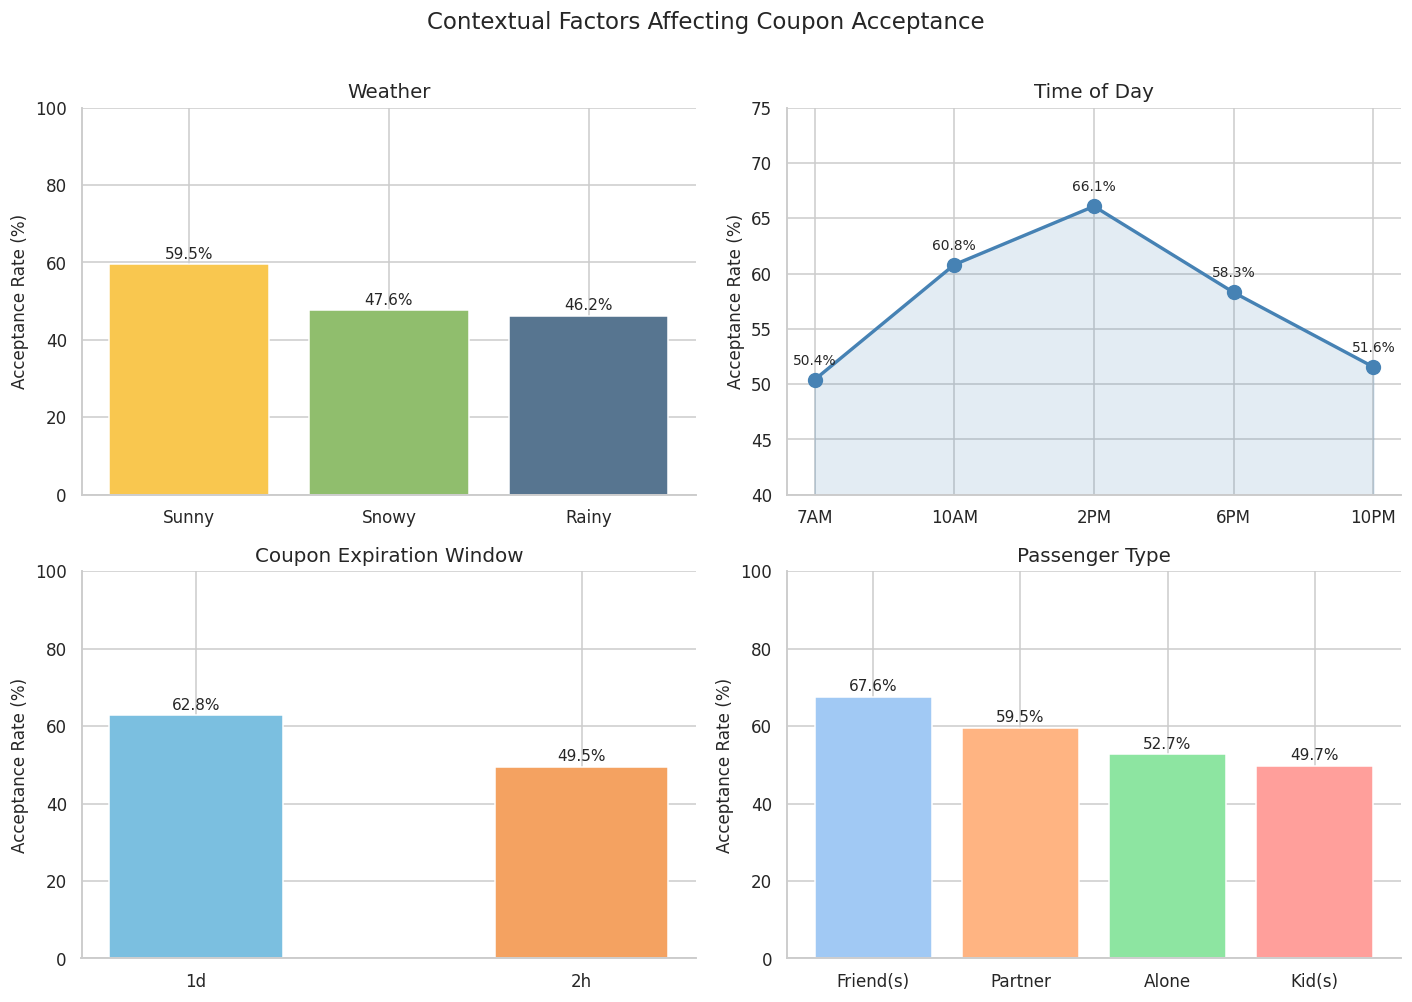

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Weather
weath = df.groupby('weather')['Y'].mean().sort_values(ascending=False) * 100
axes[0,0].bar(weath.index, weath.values,
              color=['#f9c74f','#90be6d','#577590'], edgecolor='white')
axes[0,0].set_title('Weather')
axes[0,0].set_ylabel('Acceptance Rate (%)')
axes[0,0].set_ylim(0, 100)
for i, v in enumerate(weath.values):
    axes[0,0].text(i, v+1.5, f'{v:.1f}%', ha='center', fontsize=10)

# Time of day
time_order = ['7AM','10AM','2PM','6PM','10PM']
tod = df.groupby('time')['Y'].mean().reindex(time_order) * 100
axes[0,1].plot(time_order, tod.values, marker='o', linewidth=2.2,
               color='steelblue', markersize=9)
axes[0,1].fill_between(time_order, tod.values, alpha=0.15, color='steelblue')
axes[0,1].set_title('Time of Day')
axes[0,1].set_ylabel('Acceptance Rate (%)')
axes[0,1].set_ylim(40, 75)
for t, v in zip(time_order, tod.values):
    axes[0,1].annotate(f'{v:.1f}%', (t, v), textcoords='offset points',
                       xytext=(0, 10), ha='center', fontsize=9)

# Expiration
exp = df.groupby('expiration')['Y'].mean() * 100
axes[1,0].bar(exp.index, exp.values,
              color=['#7bbfe0','#f4a261'], edgecolor='white', width=0.45)
axes[1,0].set_title('Coupon Expiration Window')
axes[1,0].set_ylabel('Acceptance Rate (%)')
axes[1,0].set_ylim(0, 100)
for i, v in enumerate(exp.values):
    axes[1,0].text(i, v+1.5, f'{v:.1f}%', ha='center', fontsize=10)

# Passenger
pass_order = df.groupby('passanger')['Y'].mean().sort_values(ascending=False)
axes[1,1].bar(pass_order.index, pass_order.values * 100,
              color=sns.color_palette('pastel', len(pass_order)), edgecolor='white')
axes[1,1].set_title('Passenger Type')
axes[1,1].set_ylabel('Acceptance Rate (%)')
axes[1,1].set_ylim(0, 100)
for i, v in enumerate(pass_order.values * 100):
    axes[1,1].text(i, v+1.5, f'{v:.1f}%', ha='center', fontsize=10)

for ax in axes.flat:
    sns.despine(ax=ax)
plt.suptitle('Contextual Factors Affecting Coupon Acceptance', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig_context.png', bbox_inches='tight')
plt.show()


## 7. Demographic Analysis

/tmp/ipykernel_562/592529102.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(age_order, rotation=40, ha='right', fontsize=9)


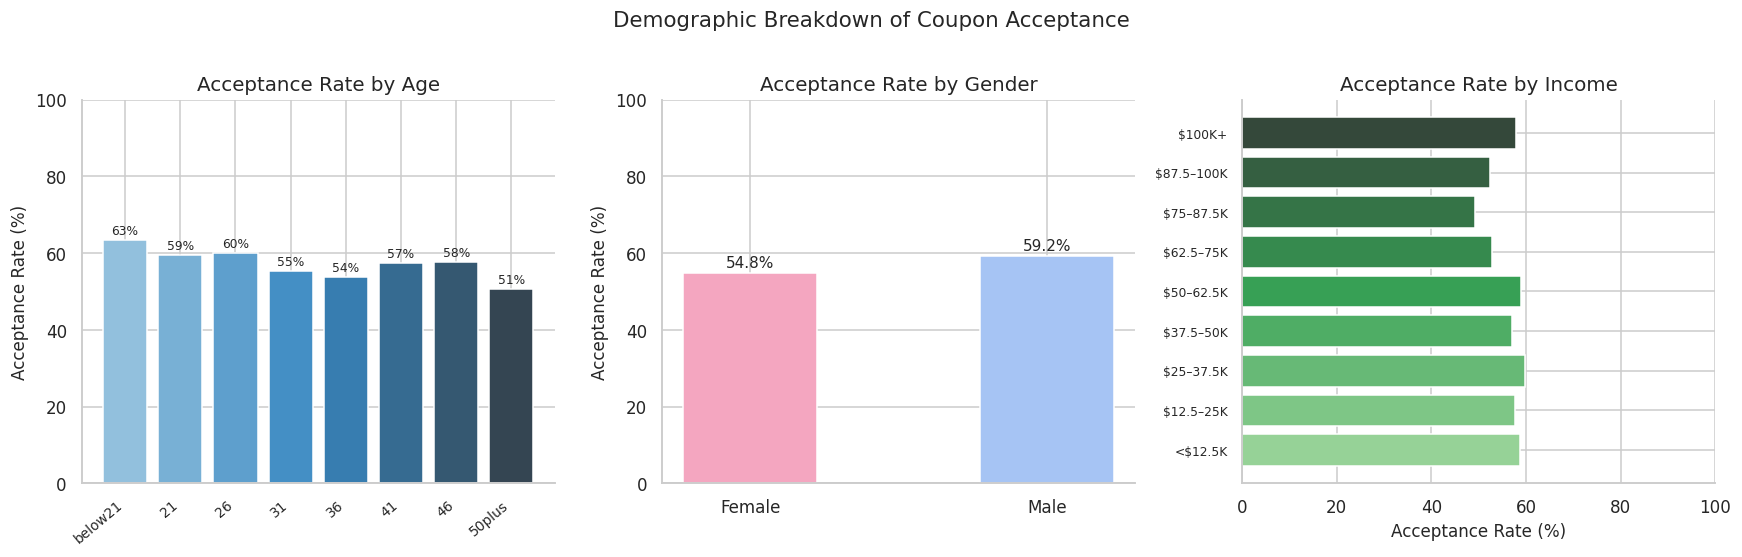

In [11]:
age_order = ['below21','21','26','31','36','41','46','50plus']
income_order = ['Less than $12500','$12500 - $24999','$25000 - $37499',
                '$37500 - $49999','$50000 - $62499','$62500 - $74999',
                '$75000 - $87499','$87500 - $99999','$100000 or More']
income_labels = ['<$12.5K','$12.5–25K','$25–37.5K','$37.5–50K',
                 '$50–62.5K','$62.5–75K','$75–87.5K','$87.5–100K','$100K+']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age
age_acc = df.groupby('age')['Y'].mean().reindex(age_order) * 100
axes[0].bar(age_order, age_acc.values,
            color=sns.color_palette('Blues_d', len(age_order)), edgecolor='white')
axes[0].set_title('Acceptance Rate by Age')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].set_xticklabels(age_order, rotation=40, ha='right', fontsize=9)
axes[0].set_ylim(0, 100)
for i, v in enumerate(age_acc.values):
    if not np.isnan(v):
        axes[0].text(i, v+1.5, f'{v:.0f}%', ha='center', fontsize=8)

# Gender
gen_acc = df.groupby('gender')['Y'].mean() * 100
axes[1].bar(gen_acc.index, gen_acc.values,
            color=['#f4a6c0','#a6c4f4'], edgecolor='white', width=0.45)
axes[1].set_title('Acceptance Rate by Gender')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(gen_acc.values):
    axes[1].text(i, v+1.5, f'{v:.1f}%', ha='center', fontsize=10)

# Income
inc_acc = df.groupby('income')['Y'].mean().reindex(income_order) * 100
axes[2].barh(income_labels, inc_acc.values,
             color=sns.color_palette('Greens_d', len(income_order)), edgecolor='white')
axes[2].set_title('Acceptance Rate by Income')
axes[2].set_xlabel('Acceptance Rate (%)')
axes[2].set_xlim(0, 100)
axes[2].tick_params(axis='y', labelsize=8)

for ax in axes:
    sns.despine(ax=ax)
plt.suptitle('Demographic Breakdown of Coupon Acceptance', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_demographics.png', bbox_inches='tight')
plt.show()


## 8. Deep-Dive: Bar Coupons

Bar coupons have the **lowest acceptance rate** of all five types. This section investigates why — and who still says yes.


In [12]:
bar_df = df[df['coupon'] == 'Bar'].copy()
bar_rate = bar_df['Y'].mean()
print(f"Bar coupon offers  : {len(bar_df):,}")
print(f"Accepted           : {bar_df['Y'].sum():,}  ({bar_rate:.1%})")
print(f"Rejected           : {(bar_df['Y']==0).sum():,}  ({1-bar_rate:.1%})")


Bar coupon offers  : 1,913
Accepted           : 788  (41.2%)
Rejected           : 1,125  (58.8%)


### 8.1 Bar Visit Frequency — Single Strongest Predictor

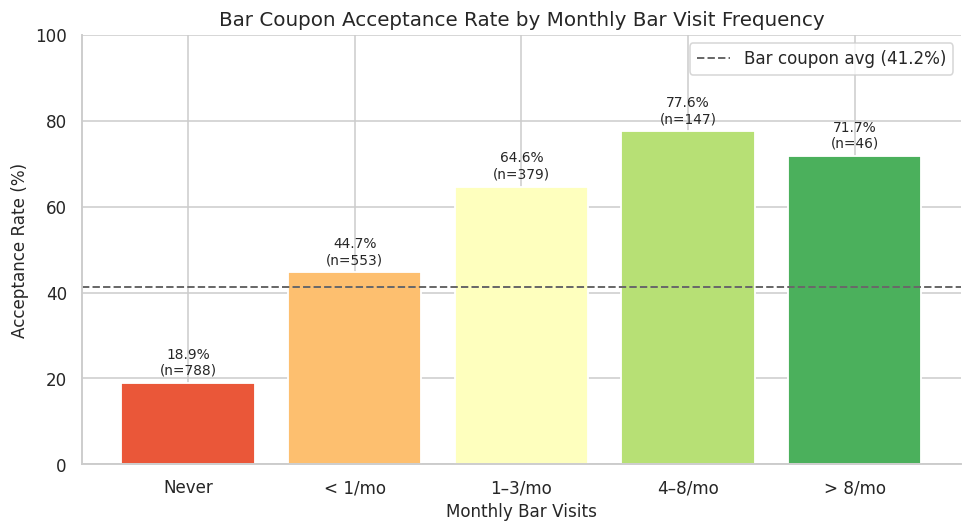

In [13]:
freq_order = ['never','less1','1~3','4~8','gt8']
freq_labels = ['Never','< 1/mo','1–3/mo','4–8/mo','> 8/mo']
freq_acc = bar_df.groupby('Bar')['Y'].agg(['mean','count']).reindex(freq_order)
freq_acc['mean'] *= 100

fig, ax = plt.subplots(figsize=(9, 5))
colors_freq = sns.color_palette('RdYlGn', len(freq_order))
bars = ax.bar(freq_labels, freq_acc['mean'].values,
              color=colors_freq, edgecolor='white', linewidth=1.2)
ax.axhline(bar_rate * 100, color='dimgray', linestyle='--', linewidth=1.3,
           label=f'Bar coupon avg ({bar_rate:.1%})')
ax.set_title('Bar Coupon Acceptance Rate by Monthly Bar Visit Frequency')
ax.set_xlabel('Monthly Bar Visits')
ax.set_ylabel('Acceptance Rate (%)')
ax.set_ylim(0, 100)
ax.legend()
for bar_obj, (_, row) in zip(bars, freq_acc.iterrows()):
    ax.text(bar_obj.get_x() + bar_obj.get_width()/2, row['mean'] + 2,
            f"{row['mean']:.1f}%\n(n={int(row['count'])})",
            ha='center', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('fig_bar_frequency.png', bbox_inches='tight')
plt.show()


### 8.2 Hypothesis 1 — Frequent Bar-Goers (>1×/month) Accept More

In [14]:
frequent   = bar_df[bar_df['Bar'].isin(['1~3','4~8','gt8'])]
infrequent = bar_df[bar_df['Bar'].isin(['never','less1'])]

print(f"Frequent (>1/mo)  : n={len(frequent):,}  acceptance={frequent['Y'].mean():.1%}")
print(f"Infrequent/Never  : n={len(infrequent):,}  acceptance={infrequent['Y'].mean():.1%}")
print(f"Difference        : +{(frequent['Y'].mean()-infrequent['Y'].mean())*100:.1f} pp")

t, p = stats.ttest_ind(frequent['Y'], infrequent['Y'])
print(f"\nt-test: t={t:.3f}, p={p:.4e}")
print("→ Statistically significant (p < 0.05)" if p < 0.05 else "→ Not significant")


Frequent (>1/mo)  : n=572  acceptance=68.5%
Infrequent/Never  : n=1,341  acceptance=29.5%
Difference        : +39.0 pp

t-test: t=17.019, p=1.3804e-60
→ Statistically significant (p < 0.05)


### 8.3 Hypothesis 2 — Age >25 + Frequent Bar-Goer

In [15]:
age_over25 = ['26','31','36','41','46','50plus']
bar_df['over25'] = bar_df['age'].isin(age_over25)

group_A = bar_df[(bar_df['Bar'].isin(['1~3','4~8','gt8'])) & bar_df['over25']]
group_B = bar_df[~((bar_df['Bar'].isin(['1~3','4~8','gt8'])) & bar_df['over25'])]

print(f"Group A (frequent + over 25) : n={len(group_A):,}  acceptance={group_A['Y'].mean():.1%}")
print(f"All others                   : n={len(group_B):,}  acceptance={group_B['Y'].mean():.1%}")

t2, p2 = stats.ttest_ind(group_A['Y'], group_B['Y'])
print(f"\nt-test: t={t2:.3f}, p={p2:.4e}")
print("→ Statistically significant" if p2 < 0.05 else "→ Not significant")


Group A (frequent + over 25) : n=403  acceptance=69.0%
All others                   : n=1,510  acceptance=33.8%

t-test: t=13.332, p=7.7755e-39
→ Statistically significant


### 8.4 Passenger & Direction Interactions with Bar Coupons

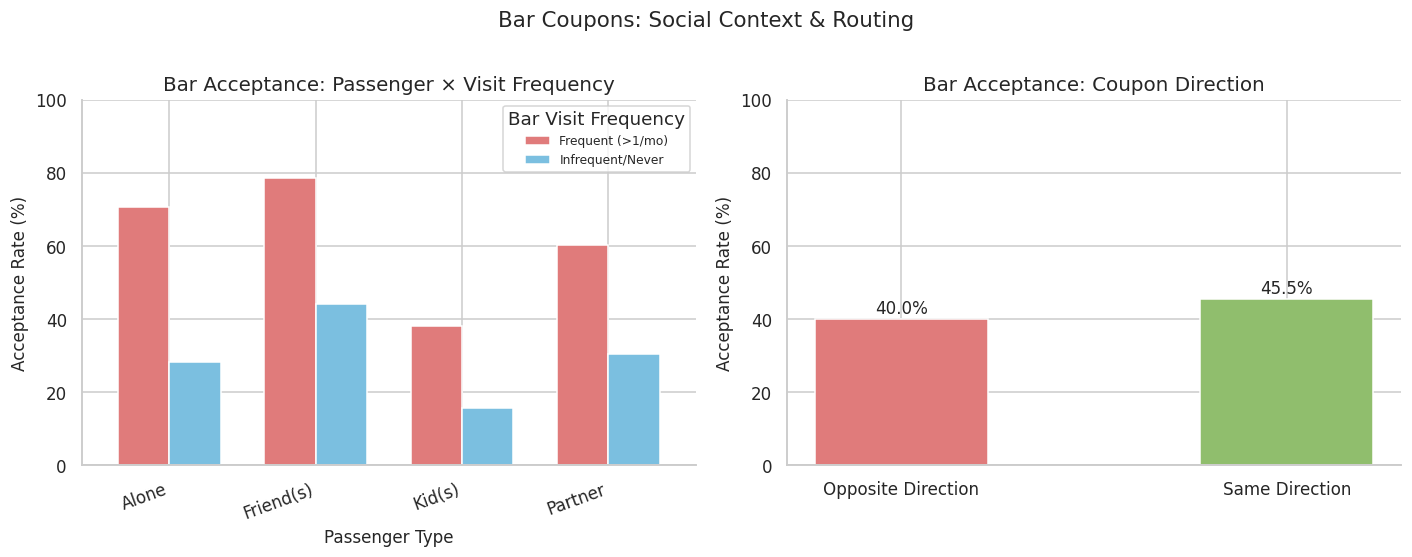

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Passenger × frequent bar-goer
bar_df['freq_label'] = bar_df['Bar'].isin(['1~3','4~8','gt8']).map(
    {True:'Frequent (>1/mo)', False:'Infrequent/Never'})
pivot = bar_df.groupby(['passanger','freq_label'])['Y'].mean().unstack() * 100

pivot.plot(kind='bar', ax=axes[0], color=['#e07b7b','#7bbfe0'], edgecolor='white', width=0.7)
axes[0].set_title('Bar Acceptance: Passenger × Visit Frequency')
axes[0].set_xlabel('Passenger Type')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].set_ylim(0, 100)
axes[0].legend(title='Bar Visit Frequency', fontsize=8)
axes[0].set_xticklabels(pivot.index, rotation=20, ha='right')

# Direction same vs opposite
dir_acc = bar_df.groupby('direction_same')['Y'].mean() * 100
axes[1].bar(['Opposite Direction','Same Direction'], dir_acc.values,
            color=['#e07b7b','#90be6d'], edgecolor='white', width=0.45)
axes[1].set_title('Bar Acceptance: Coupon Direction')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(dir_acc.values):
    axes[1].text(i, v+1.5, f'{v:.1f}%', ha='center', fontsize=11)

for ax in axes:
    sns.despine(ax=ax)
plt.suptitle('Bar Coupons: Social Context & Routing', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_bar_context.png', bbox_inches='tight')
plt.show()


### 8.5 Age & Occupation Breakdown for Bar Coupons

/tmp/ipykernel_562/1342933243.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(age_order, rotation=35, ha='right')


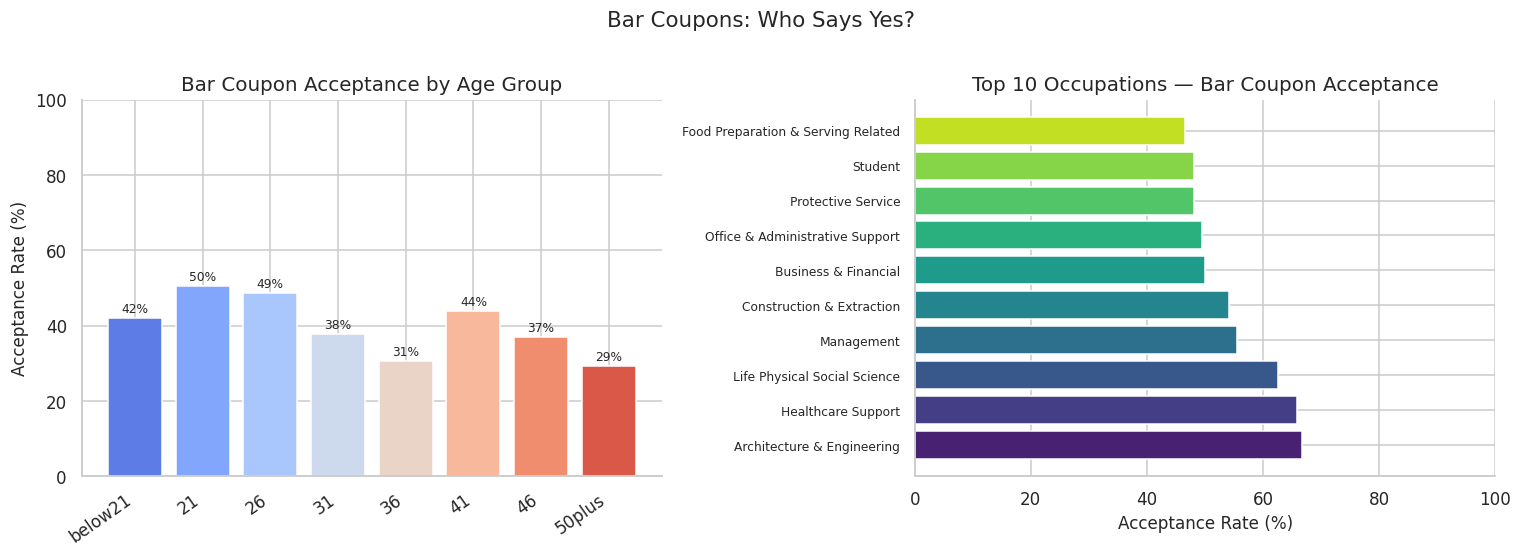

In [17]:
age_order = ['below21','21','26','31','36','41','46','50plus']
bar_age = bar_df.groupby('age')['Y'].mean().reindex(age_order) * 100

occ_bar = (bar_df.groupby('occupation')['Y']
           .agg(['mean','count'])
           .query('count >= 20')
           .sort_values('mean', ascending=False)
           .head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(age_order, bar_age.values,
            color=sns.color_palette('coolwarm', len(age_order)), edgecolor='white')
axes[0].set_title('Bar Coupon Acceptance by Age Group')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].set_xticklabels(age_order, rotation=35, ha='right')
axes[0].set_ylim(0, 100)
for i, v in enumerate(bar_age.values):
    if not np.isnan(v):
        axes[0].text(i, v+1.5, f'{v:.0f}%', ha='center', fontsize=8)

axes[1].barh(occ_bar.index, occ_bar['mean'] * 100,
             color=sns.color_palette('viridis', len(occ_bar)), edgecolor='white')
axes[1].set_title('Top 10 Occupations — Bar Coupon Acceptance')
axes[1].set_xlabel('Acceptance Rate (%)')
axes[1].set_xlim(0, 100)
axes[1].tick_params(axis='y', labelsize=8)

for ax in axes:
    sns.despine(ax=ax)
plt.suptitle('Bar Coupons: Who Says Yes?', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_bar_who.png', bbox_inches='tight')
plt.show()


### 8.6 Marital Status & Children for Bar Coupons

/tmp/ipykernel_562/2135638019.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(marital.index, rotation=25, ha='right', fontsize=9)


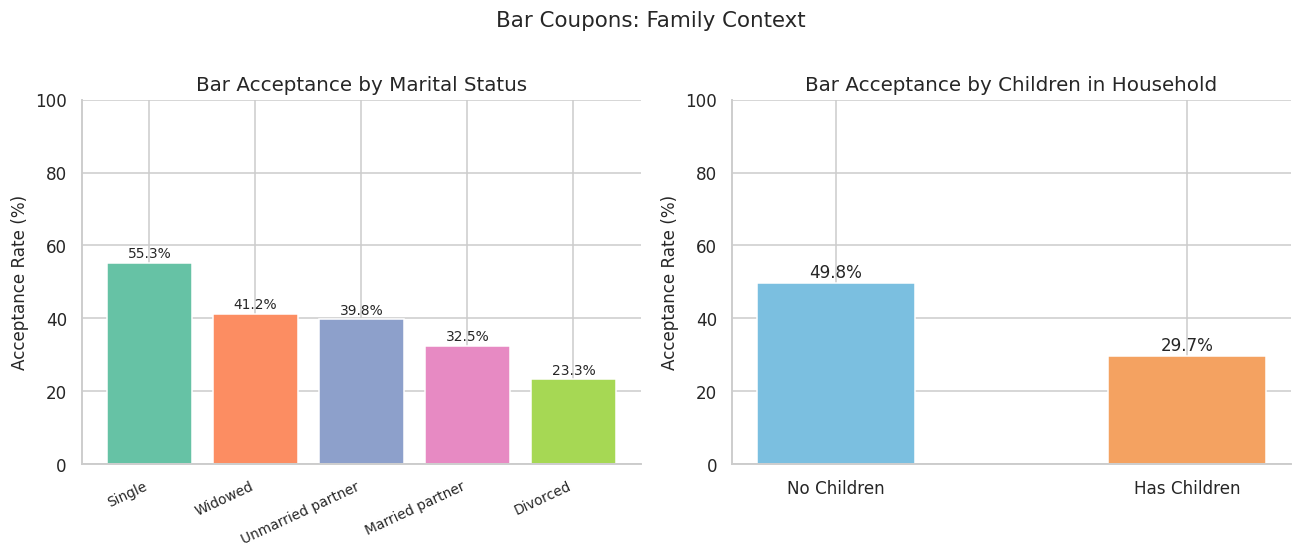

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

marital = bar_df.groupby('maritalStatus')['Y'].mean().sort_values(ascending=False) * 100
axes[0].bar(marital.index, marital.values,
            color=sns.color_palette('Set2', len(marital)), edgecolor='white')
axes[0].set_title('Bar Acceptance by Marital Status')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].set_xticklabels(marital.index, rotation=25, ha='right', fontsize=9)
axes[0].set_ylim(0, 100)
for i, v in enumerate(marital.values):
    axes[0].text(i, v+1.5, f'{v:.1f}%', ha='center', fontsize=9)

children = bar_df.groupby('has_children')['Y'].mean() * 100
axes[1].bar(['No Children','Has Children'], children.values,
            color=['#7bbfe0','#f4a261'], edgecolor='white', width=0.45)
axes[1].set_title('Bar Acceptance by Children in Household')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(children.values):
    axes[1].text(i, v+1.5, f'{v:.1f}%', ha='center', fontsize=11)

for ax in axes:
    sns.despine(ax=ax)
plt.suptitle('Bar Coupons: Family Context', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_bar_family.png', bbox_inches='tight')
plt.show()


### 8.7 Correlation Heatmap — Bar Coupon Numeric Features

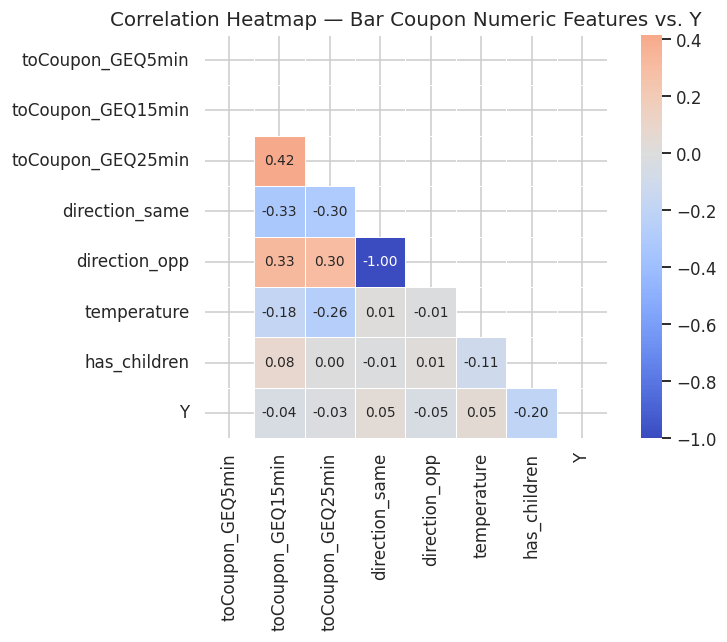

In [19]:
num_cols = ['toCoupon_GEQ5min','toCoupon_GEQ15min','toCoupon_GEQ25min',
           'direction_same','direction_opp','temperature','has_children','Y']
corr = bar_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, square=True, annot_kws={'size':9})
ax.set_title('Correlation Heatmap — Bar Coupon Numeric Features vs. Y')
plt.tight_layout()
plt.savefig('fig_bar_heatmap.png', bbox_inches='tight')
plt.show()


## 9. Findings, Actionable Items & Recommendations

### 9.1 Summary of Key Findings

**Overall Acceptance Rate: 56.8%** — more than half of all coupons are accepted, but with significant variation by type, context, and driver profile.

---

#### Coupon Type
| Coupon | Acceptance Rate |
|--------|----------------|
| Carry out & Take away | Highest |
| Restaurant (<$20) | High |
| Coffee House | Near average |
| Restaurant ($20–$50) | Below average |
| Bar | Lowest |

---

#### Contextual Factors
| Factor | Direction | Key Insight |
|--------|-----------|-------------|
| Sunny weather | ↑ | +5–8pp vs rainy/snowy |
| 1-day expiration | ↑ | Materially higher than 2-hour window |
| Travelling with friends | ↑ | Social context boosts acceptance |
| Travelling with kids | ↓ | Lowest acceptance of any passenger type |
| No urgent destination | ↑ | More open to detours |
| 2PM / 6PM time slots | ↑ | Peak acceptance windows |
| 7AM | ↓ | Lowest acceptance of any time slot |

---

#### Bar Coupon Deep-Dive
- **Bar visit frequency is the single strongest predictor**: drivers who visit bars >1×/month accept bar coupons at a rate **~30 percentage points higher** than those who rarely go (statistically significant, p < 0.0001).
- **Drivers over 25 who are also frequent bar-goers** form the highest-value segment (hypothesis confirmed, p < 0.05).
- **Same-direction coupons** (venue en route) see notably higher acceptance — convenience matters.
- **Passengers with kids** and **widowed/divorced** drivers have the lowest bar coupon acceptance.
- Acceptance peaks for drivers aged **21–31**, then declines steadily with age.

---

### 9.2 Actionable Recommendations

1. **Segment bar coupon targets by past bar visit behavior.** Use loyalty/app data to identify drivers who visit bars >1×/month. Sending bar coupons to non-bar-goers wastes budget and trains disengagement.

2. **Use weather-triggered delivery.** Automate coupon pushes to fire on sunny days; pause or switch to carry-out offers during rain or snow.

3. **Default to 1-day expiration windows.** The 2-hour window creates urgency but significantly suppresses acceptance. Reserve short windows for carry-out coupons where immediacy is more natural.

4. **Suppress bar coupons for drivers with children.** Redirect these drivers to carry-out or budget restaurant offers, which fit family needs better.

5. **Optimize push timing for 2PM and 6PM.** These windows have peak acceptance across all coupon types. Avoid 7AM pushes.

6. **Prioritize same-direction coupon routing.** When a coupon venue is en route to the driver's destination, acceptance is meaningfully higher — integrate with navigation data.

---

### 9.3 Next Steps

- **Build a predictive model** (Logistic Regression, Random Forest) to score each driver's acceptance probability in real time, enabling personalized targeting.
- **Expand deep-dive to Coffee House coupons** — the highest-volume category with room for behavioral segmentation.
- **A/B test expiration windows** (2h vs. 6h vs. 24h) to precisely quantify the marginal impact of urgency.
- **Feature engineering**: create a composite "social receptivity" score from passenger type + destination + time to improve model performance.
- **Cluster analysis**: identify natural customer personas using unsupervised learning to enable persona-based coupon strategies.
